In [1]:
from testflows.combinatorics import Covering
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn import svm
import random
from sklearn.neighbors import KNeighborsClassifier
from numpy import inf
import time
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
import umap


d:\Tesis\icafs\icafs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import opfython.math.general as g
import opfython.stream.parser as p
import opfython.stream.splitter as s
from opfython.models import SupervisedOPF
from opfython.stream import loader
from opfython.utils import logging

Load data set

In [4]:
df_cis = pd.read_csv('../data/cis_data.csv')
df_cacao = pd.read_csv(r'..\\data\\data_temp\\cacao.csv')
df_algarrobo = pd.read_csv(r'..\\data\\data_temp\\algarrobo.csv')
df_fruits_pures = pd.read_csv(r'../data/data_temp/MIR_Fruit_purees.csv')
df_fresh_meat = pd.read_csv(r'../data/data_temp/Fresh_meats.csv')
df_olive = pd.read_csv(r'../data/data_temp/Olive_Oils_Quadrum.csv')


df_x_cacao = df_cacao.iloc[:, 1:]
y_cacao = df_cacao.iloc[:, 0:1]
X_cacao = (df_x_cacao-df_x_cacao.min())/(df_x_cacao.max()-df_x_cacao.min())

algarrobo_x = df_algarrobo.loc[:, 'R':'REDVI']
y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])
X_algarrobo = (algarrobo_x-algarrobo_x.min())/(algarrobo_x.max()-algarrobo_x.min())

cis_x = df_cis[['X', 'Y', 'X10', 'Y10', 'X20', 'Y20', 'X30', 'Y30', 'X40', 'Y40']]
y_cis = df_cis[['Result']]




unique_names_berry = df_fruits_pures["label"].unique()
fruits_pures_x = df_fruits_pures.iloc[:,1:]
y_fruit_puree = df_fruits_pures.iloc[:,0:1].replace(to_replace=unique_names_berry, value =range(0,len(unique_names_berry)))
X_fruit_puree = (fruits_pures_x-fruits_pures_x.min())/(fruits_pures_x.max()-fruits_pures_x.min())


unique_names_meat = df_fresh_meat["meat"].unique()
meat_x = df_fresh_meat.iloc[:,4:]
y_meat = df_fresh_meat.iloc[:,0:1].replace(to_replace=unique_names_meat,value=range(0,len(unique_names_meat)))
X_meat =  (meat_x-meat_x.min())/(meat_x.max()-meat_x.min())

unique_names_olive = df_olive["Provenance"].unique()
olive_x = df_olive.iloc[:,3:]
y_olive = df_olive.iloc[:,2:3].replace(to_replace=unique_names_olive,value=range(0,len(unique_names_olive)))
X_olive =  (olive_x-olive_x.min())/(olive_x.max()-olive_x.min())

X_cis = (cis_x-cis_x.min())/(cis_x.max()-cis_x.min())

C:\Users\robma\AppData\Local\Temp\ipykernel_20360\3692233082.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])
C:\Users\robma\AppData\Local\Temp\ipykernel_20360\3692233082.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_fruit_puree = df_fruits_pures.iloc[:,0:1].replace(to_replace=unique_names_berry, value =range(0,len(unique_names_berry)))
C:\Users\robma\AppData\Local\Temp\ipykernel_20360\3692233082.py:31: FutureWarning: Downcasting behavio

In [5]:
def ICAFS(dataset_X, dataset_Y, strenght,max_iteartion,model, print_logs=False):

  max_it = 1 
  score_list = []
  featur_list = []
  iter_list = []
  
  v_variable = [0, 1]
  best_f1_score = float('-inf')
  max_iteartion_aux =  max_iteartion
  best_data_set = dataset_X.columns.values.copy()

  initial_test_training(score_list,iter_list,featur_list,dataset_X,dataset_Y,model)
  while max_iteartion_aux > 0:

      dict_parameters = {}
      partial_best_list = []
      partial_score = 0
      for colum_key in best_data_set:
          dict_parameters[colum_key] = v_variable
      random.shuffle(best_data_set)
      generate_covering_array = Covering(dict_parameters, strength=strenght)
      for test in generate_covering_array.array:
          list_attributes_to_consider = []

          check_for_all_cero = True
          for (test_key, test_value) in test.items():
              if test_value == 1:
                  check_for_all_cero = False
                  list_attributes_to_consider.append(test_key)

          if check_for_all_cero:
              continue  
          df_temp = dataset_X[list_attributes_to_consider]
          clf_new = train_model(model)
          score = cross_val_score(clf_new,df_temp.values, dataset_Y.values.ravel(), cv=5, scoring='f1_macro')
          final_score = score.mean()

          if final_score >= partial_score :
              partial_score = final_score
              partial_best_list = list_attributes_to_consider
          clf_new = None
      best_data_set = partial_best_list.copy()
      best_f1_score = partial_score
      
      if print_logs:
        print(f"best f1 score= {best_f1_score}, iteration:{max_it}, numbers features selected ={ len(best_data_set)},best features selected={', '.join(best_data_set)}" )

      iter_list.append(max_it)
      aux_data_score = best_f1_score
      score_list.append(aux_data_score)
      max_iteartion_aux = max_iteartion_aux-1
      max_it = max_it +1
      featur_list.append(len(best_data_set))
  return iter_list,featur_list,score_list

def initial_test_training(score_list, iter_list, feature_list ,X,y,model):
     X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X.values, y.values.ravel(), test_size=0.20, random_state=42)
     clf_new = train_model(model)
     clf_new.fit(X_train_temp, y_train_temp)
     y_pred = clf_new.predict(X_test_temp)
     score_list.append(f1_score(y_test_temp, y_pred,average='macro'))
     feature_list.append(X.shape[1])
     iter_list.append(0)

def train_model(model_name):  
    m = eval(model_name)
    return m

In [6]:
def  plot_results_for_covering_array(scores,feature,num_of_iterarion, path_to_save_image):
        color = 'tab:blue'
        res_scores = np.array(scores)
        res_features = np.array(feature)
        res_iter = np.array(num_of_iterarion)

        plt.figure(figsize=(11, 10))
        
        fig, ax1 = plt.subplots()
        barwidth = 0.4
        color = 'tab:red'
        ax1.set_xlabel('Iterations')
        ax1.set_ylabel('Number of features', color=color)
        #ax1.set_title("ICAFS Feature selection on the Cacao dataset")
        ax1.spines['top'].set_visible(False)
        ax1.bar(res_iter-0.2, res_features, color=color, width=barwidth)
        ax1.tick_params(axis='y', labelcolor=color,labelrotation=45)
        ax1.set_ylim(1,max(res_features)+3)
        ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
        
        for bar in ax1.patches:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width() / 2.0, height, f' {height}', fontsize=10,
                    ha='center', va='bottom', rotation=90)
            
        ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
        color = 'tab:blue'
        ax2.set_ylabel('F1_score', color=color)
        ax2.bar(res_iter+0.2, res_scores, color=color, width=barwidth)
        ax2.tick_params(axis='y', labelcolor=color,labelrotation=45)
        ax2.set_ylim(min(res_scores)-0.001, max(res_scores)+0.001)

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
       
        for bar in ax2.patches:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width() / 2.0, height, f' {height:.2f}', fontsize=10,
                    ha='center', va='bottom', rotation=90)

        #plt.title('ICAFS Feature selection for Cacao Dataset with OPF', y=-0.20)
        plt.gca().set_frame_on(False)
        plt.savefig(path_to_save_image)

In [7]:

from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


def plot_original_vs_reduced_umap(df_reduced_dataset,df_complete, y_dataset_integer,unique_classes):
    umap_3d = umap.UMAP(n_components=3)
    
    X_reduced_standarized = StandardScaler().fit_transform(df_reduced_dataset)
    X_complete_standarized  = StandardScaler().fit_transform(df_complete)
    
    reduced_umap = umap_3d.fit_transform(X_reduced_standarized)
    complete_umap = umap_3d.fit_transform(X_complete_standarized)
  
    fig = plt.figure(figsize=plt.figaspect(0.5))
    y_dataset_flatten = y_dataset_integer.values.ravel()

    print(unique_classes)
    ax = fig.add_subplot(1, 2, 1, projection='3d')
    for i in range(0,len(unique_classes)): 
        indices = np.where(y_dataset_flatten == i)
        ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
    plt.legend()
    #ax.scatter(complete_umap[:,0], complete_umap[:,1], complete_umap[:,2], c=[sns.color_palette()[x] for x in y_dataset_flatten],marker = "v",label=unique_classes[0])
    
    ax = fig.add_subplot(1, 2, 2, projection='3d')
    for i in range(0,len(unique_classes)): 
        indices = np.where(y_dataset_flatten == i)
        ax.scatter(reduced_umap[indices,0], reduced_umap[indices,1], reduced_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])

    #ax.scatter(reduced_umap[:,0], reduced_umap[:,1], reduced_umap[:,2], c=[sns.color_palette()[x] for x in y_dataset_flatten],marker = "v",label=unique_classes[0])
    plt.legend()
    
    plt.show()
   

ICAFS KNN

best f1 score= 0.9017056611956772, iteration:1, numbers features selected =799,best features selected=1103, 1696, 1697, 1698, 1699, 1700, 1701, 1702, 1703, 1704, 1705, 1706, 1707, 1708, 1709, 1710, 1711, 1712, 1713, 1714, 1715, 1716, 1717, 1718, 1720, 1721, 1722, 1723, 1724, 1725, 1726, 1728, 1729, 1730, 1731, 1732, 1733, 1734, 1735, 1736, 1737, 1738, 1739, 1740, 1741, 1742, 1743, 1744, 1745, 1746, 1747, 1748, 1749, 1750, 1752, 1753, 1754, 1755, 1756, 1757, 1758, 1759, 1760, 1761, 1762, 1763, 1764, 1765, 1766, 1767, 1768, 1769, 1770, 1771, 1772, 1773, 1774, 1775, 1776, 1777, 1778, 1779, 1780, 1781, 1782, 1783, 1784, 1785, 1786, 1787, 1788, 1789, 1790, 1791, 1792, 1793, 1794, 1795, 1796, 1797, 1798, 1799, 1800, 1801, 1802, 1803, 1804, 1805, 1806, 1807, 1808, 1809, 1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1848, 1849

<Figure size 1100x1000 with 0 Axes>

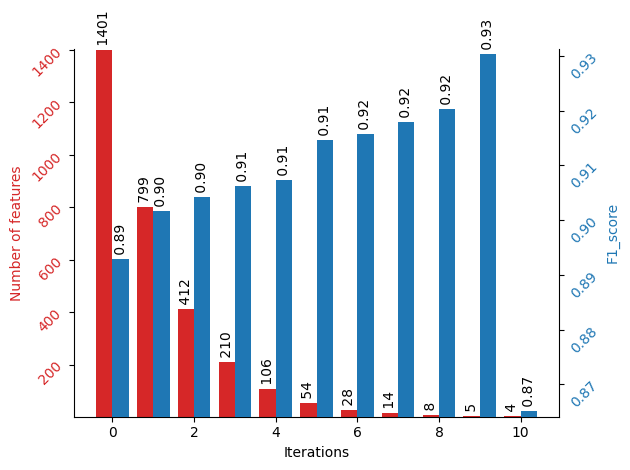

In [10]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cacao,y_cacao,2,10,'KNeighborsClassifier(n_neighbors=2)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'./output_images/cacao_knn_icafs.png')

In [ ]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,'KNeighborsClassifier(n_neighbors=3)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_knn_icafs.png')

best f1 score= 0.9571730048089891, iteration:1, numbers features selected =156,best features selected=907.047, 1018.987, 1026.707, 1030.567, 1034.427, 1038.287, 1042.147, 1046.007, 1049.867, 1053.727, 1057.587, 1061.447, 1065.307, 1069.167, 1073.027, 1076.887, 1080.747, 1084.607, 1088.467, 1092.327, 1096.187, 1100.047, 1103.907, 1107.767, 1111.627, 1115.487, 1119.347, 1123.207, 1127.067, 1130.927, 1134.786, 1138.646, 1142.506, 1146.366, 1150.226, 1154.086, 1157.946, 1161.806, 1165.666, 1169.526, 1173.386, 1177.246, 1181.106, 1184.966, 1188.826, 1192.686, 1196.546, 1200.406, 1204.266, 1208.126, 1211.986, 1215.846, 1219.706, 1223.566, 1227.426, 1231.286, 1235.146, 1239.006, 1242.866, 1246.726, 1250.586, 1254.446, 1258.306, 1262.166, 1266.026, 1269.886, 1273.746, 1277.606, 1281.466, 1285.326, 1289.186, 1293.046, 1296.906, 1300.766, 1304.626, 1308.486, 1312.346, 1316.206, 1320.066, 1323.926, 1327.786, 1331.646, 1335.506, 1339.366, 1343.226, 1347.086, 1350.946, 1354.806, 1358.666, 1362.526,

<Figure size 1100x1000 with 0 Axes>

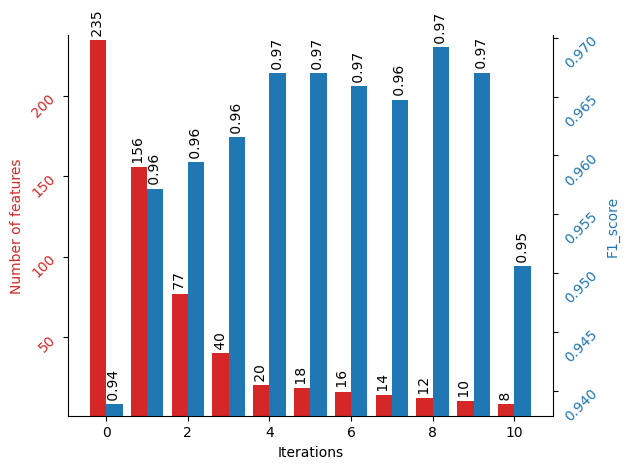

In [6]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_fruit_puree,y_fruit_puree,2,10,'KNeighborsClassifier(n_neighbors=3)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\fruit_puree_knn_icafs.png')

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


['Not Strawberry' 'Strawberry']


C:\Users\robma\AppData\Local\Temp\ipykernel_15384\3654617813.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
C:\Users\robma\AppData\Local\Temp\ipykernel_15384\3654617813.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(reduced_umap[indices,0], reduced_uma

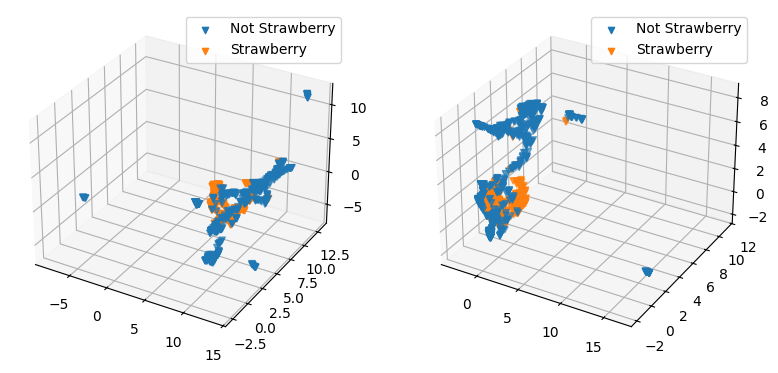

In [7]:
plot_original_vs_reduced_umap(X_fruit_puree[['1404.985', '1443.585', '1474.465', '1516.925', '1609.565', '1679.044', '1771.684', '1802.564']],X_fruit_puree,y_fruit_puree,unique_names_berry)

best f1 score= 0.9747027699968877, iteration:1, numbers features selected =270,best features selected=1018.856, 1344.9525, 1346.882, 1348.8115, 1350.741, 1352.6705, 1354.6, 1356.5295, 1358.459, 1360.3885, 1362.318, 1364.2485, 1366.178, 1368.1075, 1370.037, 1371.9665, 1375.8255, 1377.755, 1379.6845, 1381.614, 1383.5435, 1385.473, 1387.4025, 1389.332, 1391.2615, 1393.191, 1395.1205, 1397.05, 1398.9805, 1400.91, 1402.8395, 1404.769, 1406.6985, 1408.628, 1410.5575, 1412.487, 1414.4165, 1416.346, 1418.2755, 1420.205, 1422.1345, 1424.064, 1425.9935, 1427.923, 1429.8525, 1431.782, 1433.7125, 1435.642, 1437.5715, 1439.501, 1441.4305, 1443.36, 1445.2895, 1447.219, 1449.1485, 1451.078, 1453.0075, 1454.937, 1456.8675, 1458.797, 1460.7265, 1462.656, 1464.5855, 1468.4445, 1470.374, 1472.3035, 1474.233, 1476.1625, 1478.092, 1480.0215, 1481.951, 1483.8805, 1485.81, 1487.7395, 1489.669, 1491.5995, 1493.529, 1495.4585, 1499.3175, 1501.247, 1503.1765, 1505.106, 1507.0355, 1508.965, 1510.8945, 1512.824, 

<Figure size 1100x1000 with 0 Axes>

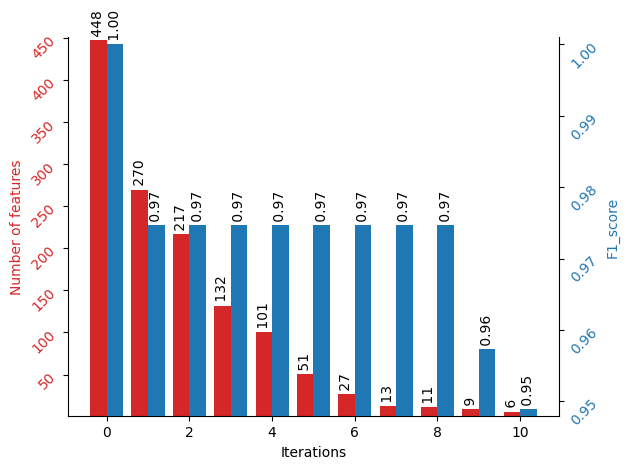

In [8]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_meat,y_meat,2,10,'KNeighborsClassifier(n_neighbors=3)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\meat_knn_icafs.png')

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


['Chicken' 'Pork' 'Turkey']


C:\Users\robma\AppData\Local\Temp\ipykernel_15384\3654617813.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
C:\Users\robma\AppData\Local\Temp\ipykernel_15384\3654617813.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(reduced_umap[indices,0], reduced_uma

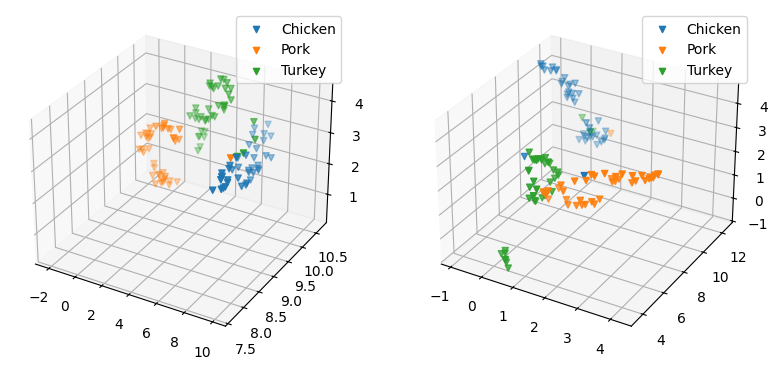

In [9]:
plot_original_vs_reduced_umap(X_meat[['1634.3875', '1713.499', '1719.2875', '1746.3015', '1836.991', '1842.7805']], X_meat,y_meat,unique_names_meat)

best f1 score= 0.8873252371123888, iteration:1, numbers features selected =287,best features selected=802.751, 827.8345, 831.6935, 833.623, 835.5525, 837.482, 839.4115, 841.341, 843.2705, 845.2, 847.1295, 849.059, 850.9885, 852.918, 854.8475, 856.777, 858.7065, 860.636, 868.354, 870.2835, 872.213, 876.072, 881.8605, 883.79, 885.7195, 887.649, 891.508, 893.4375, 895.367, 905.0145, 908.8735, 910.803, 920.4505, 928.1685, 930.098, 932.0275, 933.957, 937.816, 943.6045, 945.534, 947.4645, 949.394, 953.253, 955.1825, 957.112, 966.7595, 970.6185, 972.548, 974.4775, 982.1955, 989.9135, 991.843, 993.7725, 995.702, 999.561, 1007.279, 1009.2085, 1011.138, 1014.997, 1016.9265, 1018.856, 1028.5035, 1032.3625, 1034.292, 1036.2215, 1043.9405, 1051.6585, 1053.588, 1055.5175, 1057.447, 1061.306, 1069.024, 1070.9535, 1072.883, 1076.743, 1078.6725, 1080.602, 1090.2495, 1094.1085, 1096.038, 1097.9675, 1105.6855, 1113.4045, 1115.334, 1117.2635, 1119.193, 1123.052, 1130.77, 1132.7005, 1134.63, 1138.489, 1140

<Figure size 1100x1000 with 0 Axes>

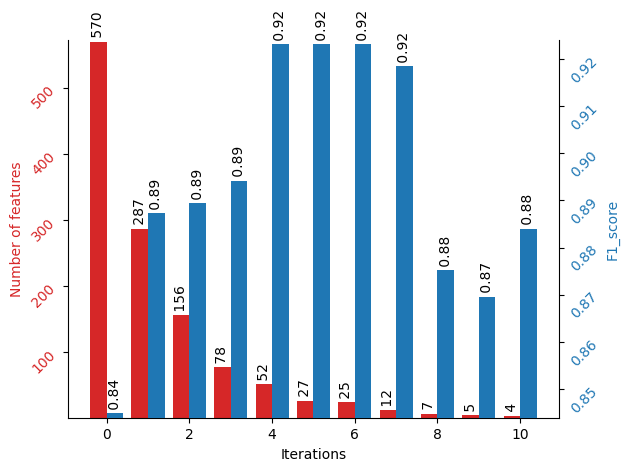

In [10]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_olive,y_olive,2,10,'KNeighborsClassifier(n_neighbors=2)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\olive_icafs.png')

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


['Greece' 'Italy' 'Portugal' 'Spain']


C:\Users\robma\AppData\Local\Temp\ipykernel_15384\3654617813.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
C:\Users\robma\AppData\Local\Temp\ipykernel_15384\3654617813.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(reduced_umap[indices,0], reduced_uma

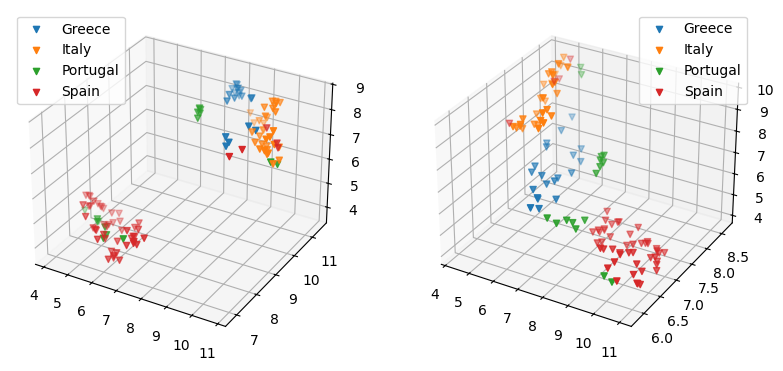

In [13]:
plot_original_vs_reduced_umap(X_olive[['1032.3625', '1130.77', '1180.939', '1217.6005', '1261.981', '1370.037', '1427.923', '1464.5855', '1508.965', '1617.021', '1674.908']],X_olive,y_olive,unique_names_olive)

best f1 score= 0.9790925773245351, iteration:1, numbers features selected =4,best features selected=X, Y, X40, Y40
best f1 score= 0.9902991873397463, iteration:2, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9902991873397463, iteration:3, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9902991873397463, iteration:4, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9902991873397463, iteration:5, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9902991873397463, iteration:6, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9902991873397463, iteration:7, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9902991873397463, iteration:8, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9902991873397463, iteration:9, numbers features selected =3,best features selected=X, Y, Y40
best 

<Figure size 1100x1000 with 0 Axes>

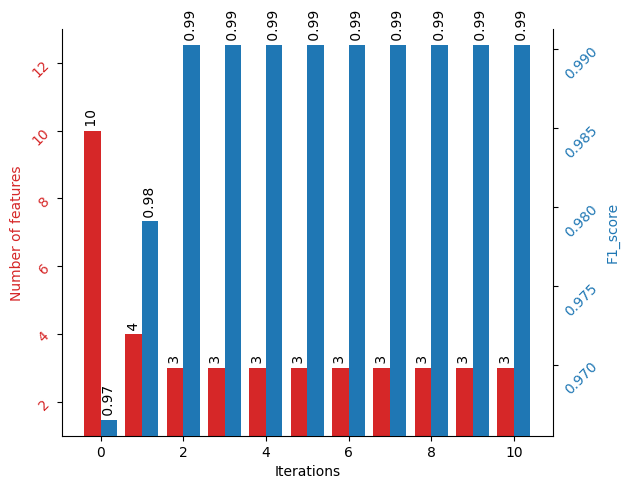

In [8]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cis,y_cis,3,10,'KNeighborsClassifier(n_neighbors=3)',True)
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cis_knn_icafs.png')

ICAFS SVC

best f1 score= 0.6737857229528509, iteration:1, numbers features selected =703,best features selected=1101, 1109, 1110, 1111, 1112, 1113, 1114, 1115, 1116, 1117, 1119, 1121, 1122, 1123, 1124, 1126, 1128, 1133, 1135, 1137, 1138, 1139, 1140, 1142, 1143, 1144, 1149, 1153, 1154, 1155, 1156, 1158, 1159, 1160, 1165, 1169, 1170, 1171, 1172, 1174, 1175, 1176, 1181, 1185, 1186, 1187, 1188, 1190, 1191, 1192, 1197, 1201, 1202, 1203, 1204, 1206, 1207, 1208, 1213, 1217, 1218, 1219, 1220, 1222, 1223, 1224, 1229, 1233, 1234, 1235, 1236, 1238, 1239, 1240, 1245, 1249, 1250, 1251, 1252, 1254, 1255, 1256, 1261, 1265, 1266, 1267, 1268, 1270, 1271, 1272, 1277, 1281, 1282, 1283, 1284, 1286, 1287, 1288, 1293, 1297, 1298, 1299, 1300, 1302, 1303, 1304, 1309, 1313, 1314, 1315, 1316, 1318, 1319, 1320, 1325, 1329, 1330, 1331, 1332, 1334, 1335, 1336, 1341, 1345, 1346, 1347, 1348, 1350, 1351, 1352, 1357, 1361, 1362, 1363, 1364, 1366, 1367, 1368, 1373, 1377, 1378, 1379, 1380, 1382, 1383, 1384, 1389, 1393, 1394, 1395

<Figure size 1100x1000 with 0 Axes>

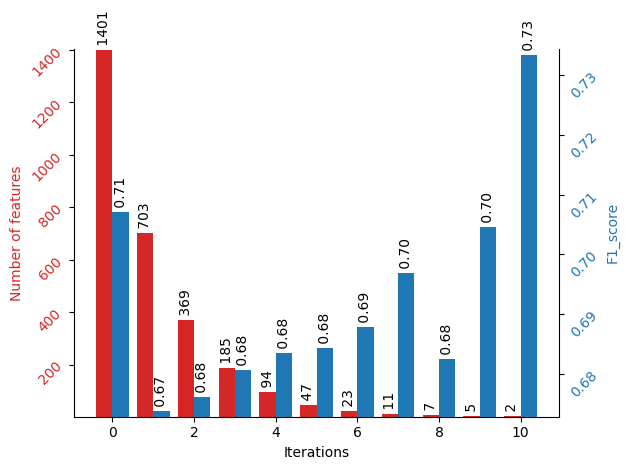

In [32]:
start_time = time.time()
iterations ,feature,score  = ICAFS(X_cacao,y_cacao,2,10,'svm.SVC()' ,True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cacao_svc_icafs.png')

best f1 score= 0.7390899498005483, iteration:1, numbers features selected =12,best features selected=Edge Red, CIVE, VEG, RGBVI, MGRVI, NDVI, RVI, DVI, REVI, NDRE, RERVI, REDVI
best f1 score= 0.7472275511961944, iteration:2, numbers features selected =7,best features selected=Edge Red, CIVE, VEG, MGRVI, RVI, REVI, RERVI
best f1 score= 0.7523170717720014, iteration:3, numbers features selected =5,best features selected=Edge Red, CIVE, VEG, RVI, RERVI
best f1 score= 0.7452878552552512, iteration:4, numbers features selected =4,best features selected=Edge Red, CIVE, VEG, RERVI
best f1 score= 0.7485400164811925, iteration:5, numbers features selected =3,best features selected=Edge Red, CIVE, VEG
best f1 score= 0.7485400164811925, iteration:6, numbers features selected =3,best features selected=Edge Red, CIVE, VEG
best f1 score= 0.7485400164811925, iteration:7, numbers features selected =3,best features selected=Edge Red, CIVE, VEG
best f1 score= 0.7485400164811925, iteration:8, numbers fea

<Figure size 1100x1000 with 0 Axes>

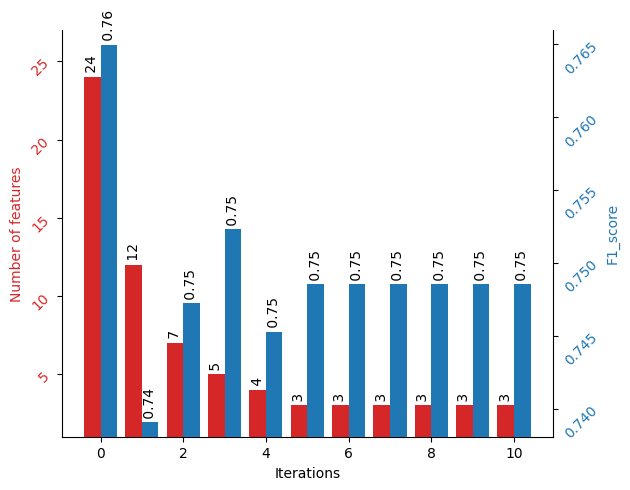

In [22]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,'svm.SVC()',True )
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_svc_icafs.png')

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


['N', 'P']


C:\Users\robma\AppData\Local\Temp\ipykernel_15384\3654617813.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
C:\Users\robma\AppData\Local\Temp\ipykernel_15384\3654617813.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(reduced_umap[indices,0], reduced_uma

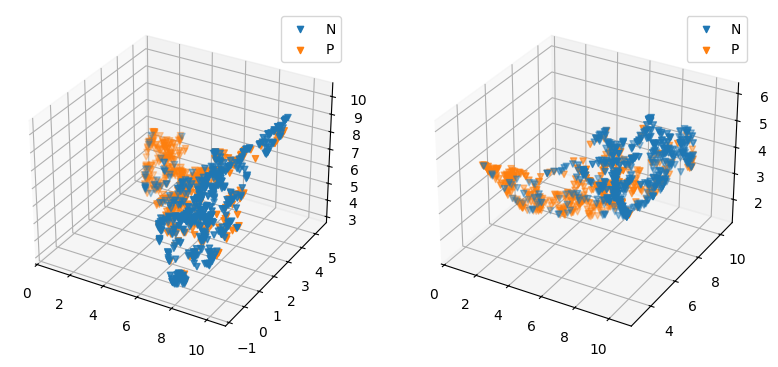

In [24]:
plot_original_vs_reduced_umap(X_algarrobo[['Edge Red', 'CIVE', 'VEG', 'RVI', 'RERVI']], X_algarrobo,y_algarrobo,['N', 'P'])

best f1 score= 0.9530766413392759, iteration:1, numbers features selected =156,best features selected=907.047, 1018.987, 1026.707, 1030.567, 1034.427, 1038.287, 1042.147, 1046.007, 1049.867, 1053.727, 1057.587, 1061.447, 1065.307, 1069.167, 1073.027, 1076.887, 1080.747, 1084.607, 1088.467, 1092.327, 1096.187, 1100.047, 1103.907, 1107.767, 1111.627, 1115.487, 1119.347, 1123.207, 1127.067, 1130.927, 1134.786, 1138.646, 1142.506, 1146.366, 1150.226, 1154.086, 1157.946, 1161.806, 1165.666, 1169.526, 1173.386, 1177.246, 1181.106, 1184.966, 1188.826, 1192.686, 1196.546, 1200.406, 1204.266, 1208.126, 1211.986, 1215.846, 1219.706, 1223.566, 1227.426, 1231.286, 1235.146, 1239.006, 1242.866, 1246.726, 1250.586, 1254.446, 1258.306, 1262.166, 1266.026, 1269.886, 1273.746, 1277.606, 1281.466, 1285.326, 1289.186, 1293.046, 1296.906, 1300.766, 1304.626, 1308.486, 1312.346, 1316.206, 1320.066, 1323.926, 1327.786, 1331.646, 1335.506, 1339.366, 1343.226, 1347.086, 1350.946, 1354.806, 1358.666, 1362.526,

<Figure size 1100x1000 with 0 Axes>

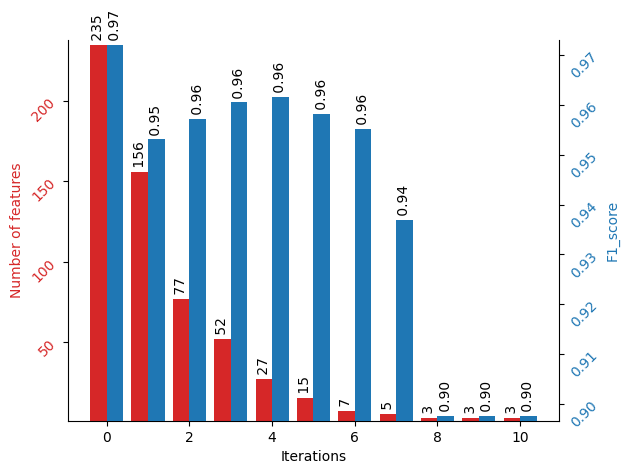

In [14]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_fruit_puree,y_fruit_puree,2,10,'svm.SVC()',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\fruit_puree_svc_icafs.png')

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


['Not Strawberry' 'Strawberry']


C:\Users\robma\AppData\Local\Temp\ipykernel_15384\3654617813.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
C:\Users\robma\AppData\Local\Temp\ipykernel_15384\3654617813.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(reduced_umap[indices,0], reduced_uma

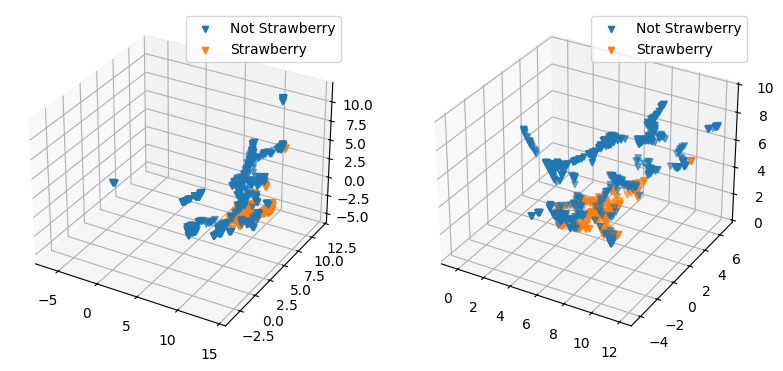

In [16]:
plot_original_vs_reduced_umap(X_fruit_puree[['1088.467', '1188.826', '1250.586', '1377.966', '1559.385']], X_fruit_puree,y_fruit_puree,unique_names_berry)

best f1 score= 0.8566204914460063, iteration:1, numbers features selected =465,best features selected=812.3985, 891.508, 893.4375, 895.367, 897.2965, 899.226, 901.1555, 903.085, 905.0145, 906.944, 908.8735, 910.803, 912.7325, 914.662, 916.5915, 918.521, 922.38, 924.3095, 926.239, 928.1685, 930.098, 932.0275, 933.957, 935.8865, 937.816, 939.7455, 941.675, 943.6045, 945.534, 947.4645, 949.394, 951.3235, 953.253, 955.1825, 957.112, 959.0415, 960.971, 962.9005, 964.83, 966.7595, 968.689, 970.6185, 972.548, 974.4775, 976.407, 978.3365, 980.266, 982.1955, 984.125, 986.0545, 987.984, 989.9135, 991.843, 993.7725, 995.702, 997.6315, 999.561, 1001.4905, 1003.42, 1005.3495, 1007.279, 1009.2085, 1011.138, 1013.0675, 1014.997, 1016.9265, 1018.856, 1020.7855, 1022.715, 1024.6445, 1026.574, 1028.5035, 1030.433, 1032.3625, 1034.292, 1036.2215, 1038.151, 1040.0815, 1042.011, 1043.9405, 1045.87, 1047.7995, 1049.729, 1051.6585, 1053.588, 1055.5175, 1057.447, 1059.3765, 1061.306, 1063.2355, 1065.165, 1067

<Figure size 1100x1000 with 0 Axes>

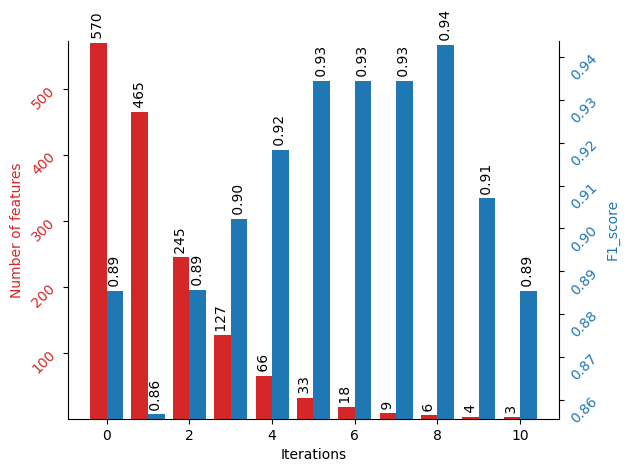

In [17]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_olive,y_olive,2,10,'svm.SVC()',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\olive_icafs_svc.png')

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


['Greece' 'Italy' 'Portugal' 'Spain']


C:\Users\robma\AppData\Local\Temp\ipykernel_15384\3654617813.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
C:\Users\robma\AppData\Local\Temp\ipykernel_15384\3654617813.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(reduced_umap[indices,0], reduced_uma

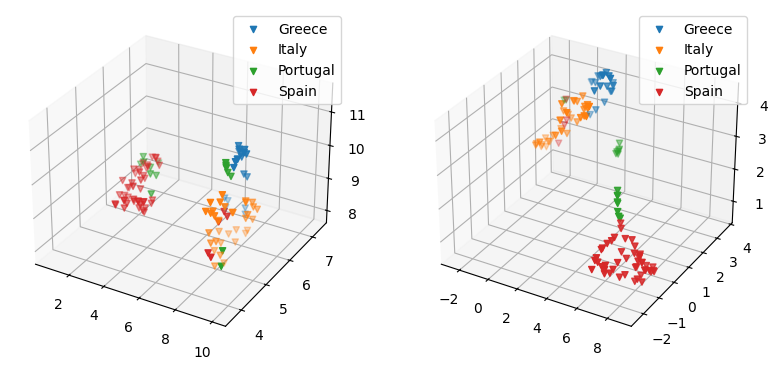

In [21]:
plot_original_vs_reduced_umap(X_olive[['968.689', '1126.911', '1250.404', '1470.374', '1603.5135', '1732.795']], X_olive,y_olive,unique_names_olive)

In [ ]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cis,y_cis,3,10,'svm.SVC()',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cis_knn_icafs.png')

ICAFS MLP

best f1 score= 0.9840875748659054, iteration:1, numbers features selected =1399,best features selected=1102, 1103, 1104, 1105, 1106, 1107, 1108, 1109, 1110, 1111, 1112, 1113, 1114, 1115, 1116, 1117, 1118, 1119, 1120, 1121, 1122, 1123, 1124, 1125, 1126, 1127, 1128, 1129, 1130, 1131, 1132, 1133, 1134, 1135, 1136, 1137, 1138, 1139, 1140, 1141, 1142, 1143, 1144, 1145, 1146, 1147, 1148, 1149, 1150, 1151, 1152, 1153, 1154, 1155, 1156, 1157, 1158, 1159, 1160, 1161, 1162, 1163, 1164, 1165, 1166, 1167, 1168, 1169, 1170, 1171, 1172, 1173, 1174, 1175, 1176, 1177, 1178, 1179, 1180, 1181, 1182, 1183, 1184, 1185, 1186, 1187, 1188, 1189, 1190, 1191, 1192, 1193, 1194, 1195, 1196, 1197, 1198, 1199, 1200, 1201, 1202, 1203, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1212, 1213, 1214, 1215, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223, 1224, 1225, 1226, 1227, 1228, 1229, 1230, 1231, 1232, 1233, 1234, 1235, 1236, 1237, 1238, 1239, 1240, 1241, 1242, 1243, 1244, 1245, 1246, 1247, 1248, 1249, 1250, 125

<Figure size 1100x1000 with 0 Axes>

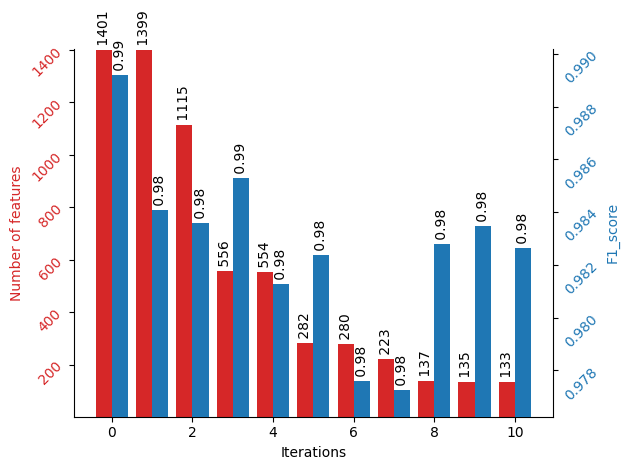

In [30]:
start_time = time.time()
iterations ,feature,score  = ICAFS(X_cacao,y_cacao,2,10,'MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)',True )
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cacao_mlp_icafs.png')

best f1 score= 0.7381033607943001, iteration:1, numbers features selected =12,best features selected=R, Edge Red, EXG, NGRDI, RGRI, GBRI.1, VEG, MGRVI, RVI, EVI, NDRE, REDVI
best f1 score= 0.7415113339989775, iteration:2, numbers features selected =6,best features selected=R, NGRDI, GBRI.1, MGRVI, EVI, REDVI
best f1 score= 0.7372492284224419, iteration:3, numbers features selected =3,best features selected=R, MGRVI, REDVI
best f1 score= 0.7292965081266294, iteration:4, numbers features selected =3,best features selected=R, MGRVI, REDVI
best f1 score= 0.7271983108120761, iteration:5, numbers features selected =3,best features selected=R, MGRVI, REDVI
best f1 score= 0.7303629060320753, iteration:6, numbers features selected =3,best features selected=R, MGRVI, REDVI
best f1 score= 0.7325327797953634, iteration:7, numbers features selected =3,best features selected=R, MGRVI, REDVI
best f1 score= 0.7352598725301881, iteration:8, numbers features selected =3,best features selected=R, MGRVI, 

<Figure size 1100x1000 with 0 Axes>

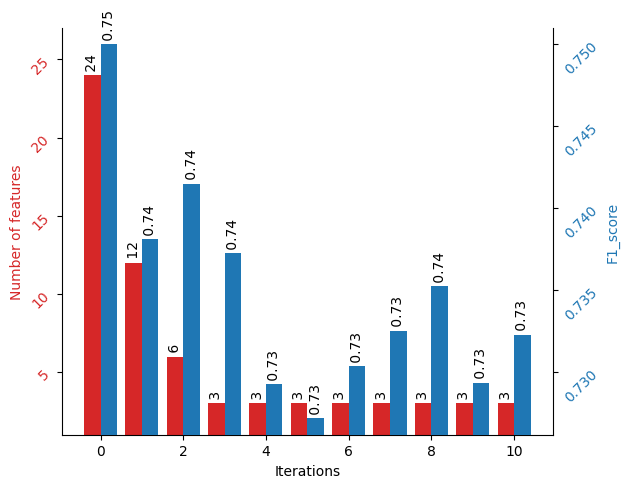

In [29]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,'MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)' ,True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_mlp_icafs.png')

best f1 score= 0.9560768149304094, iteration:1, numbers features selected =4,best features selected=X, Y, X40, Y40
best f1 score= 0.9572747142041738, iteration:2, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9571705507567738, iteration:3, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9565713809987493, iteration:4, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9569716729929276, iteration:5, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9573695607553377, iteration:6, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9568736022039612, iteration:7, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9573740751949851, iteration:8, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9570719566533714, iteration:9, numbers features selected =3,best features selected=X, Y, Y40
best 

<Figure size 1100x1000 with 0 Axes>

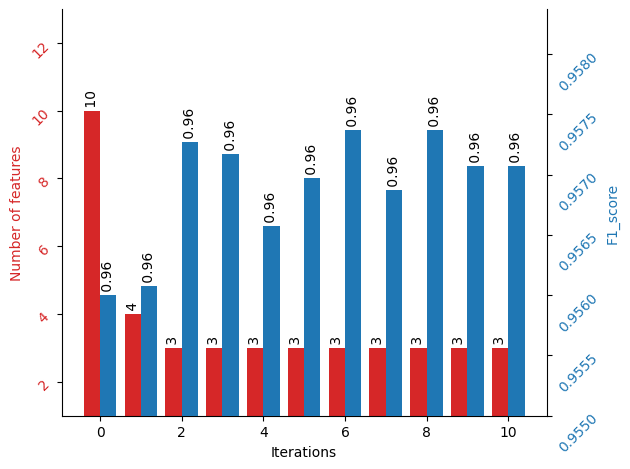

In [31]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cis,y_cis,3,10,'MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cis_mlp_icafs.png')

best f1 score= 0.9475576667332859, iteration:1, numbers features selected =149,best features selected=910.907, 1223.566, 1227.426, 1231.286, 1235.146, 1239.006, 1242.866, 1246.726, 1250.586, 1254.446, 1258.306, 1262.166, 1266.026, 1269.886, 1273.746, 1277.606, 1281.466, 1285.326, 1289.186, 1293.046, 1296.906, 1300.766, 1304.626, 1308.486, 1316.206, 1320.066, 1323.926, 1327.786, 1331.646, 1335.506, 1339.366, 1347.086, 1350.946, 1354.806, 1358.666, 1362.526, 1366.386, 1370.246, 1374.106, 1377.966, 1381.826, 1385.686, 1389.545, 1393.405, 1397.265, 1401.125, 1404.985, 1408.845, 1412.705, 1416.565, 1420.425, 1424.285, 1428.145, 1432.005, 1439.725, 1443.585, 1447.445, 1451.305, 1455.165, 1459.025, 1462.885, 1466.745, 1470.605, 1474.465, 1478.325, 1482.185, 1486.045, 1489.905, 1493.765, 1497.625, 1501.485, 1505.345, 1509.205, 1513.065, 1516.925, 1520.785, 1524.645, 1528.505, 1532.365, 1536.225, 1540.085, 1543.945, 1547.805, 1551.665, 1555.525, 1559.385, 1563.245, 1567.105, 1570.965, 1574.825,

<Figure size 1100x1000 with 0 Axes>

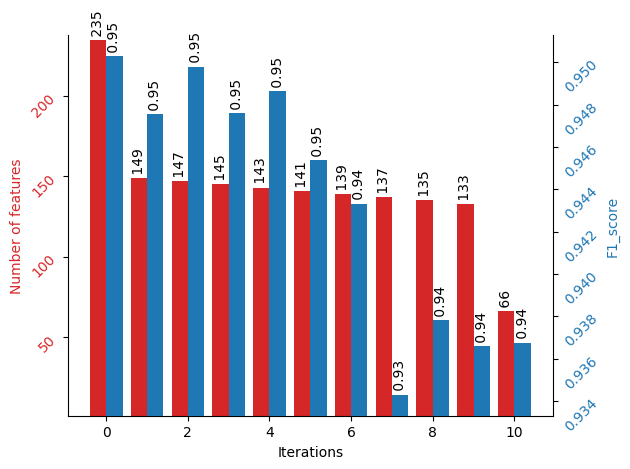

In [26]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_fruit_puree,y_fruit_puree,2,10,'MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\fruit_puree_mlp_icafs.png')

best f1 score= 0.9916339869281046, iteration:1, numbers features selected =229,best features selected=1011.138, 1028.5035, 1030.433, 1032.3625, 1034.292, 1036.2215, 1038.151, 1040.0815, 1043.9405, 1045.87, 1047.7995, 1049.729, 1051.6585, 1053.588, 1055.5175, 1057.447, 1059.3765, 1061.306, 1063.2355, 1065.165, 1067.0945, 1069.024, 1070.9535, 1080.602, 1084.461, 1086.3905, 1088.32, 1096.038, 1103.756, 1105.6855, 1107.615, 1109.5455, 1113.4045, 1119.193, 1121.1225, 1123.052, 1124.9815, 1128.8405, 1130.77, 1132.7005, 1142.348, 1146.207, 1148.1365, 1150.066, 1157.784, 1165.502, 1167.4325, 1169.362, 1171.2915, 1175.1505, 1182.8685, 1184.798, 1186.7275, 1190.5875, 1192.517, 1194.4465, 1204.094, 1207.953, 1209.8825, 1211.812, 1219.53, 1227.249, 1229.1785, 1231.108, 1233.0375, 1236.8965, 1244.6145, 1246.544, 1248.4745, 1252.3335, 1254.263, 1256.1925, 1265.84, 1269.699, 1271.6285, 1273.558, 1281.276, 1288.995, 1290.9245, 1292.854, 1294.7835, 1298.6425, 1306.3615, 1308.291, 1310.2205, 1314.0795, 

<Figure size 1100x1000 with 0 Axes>

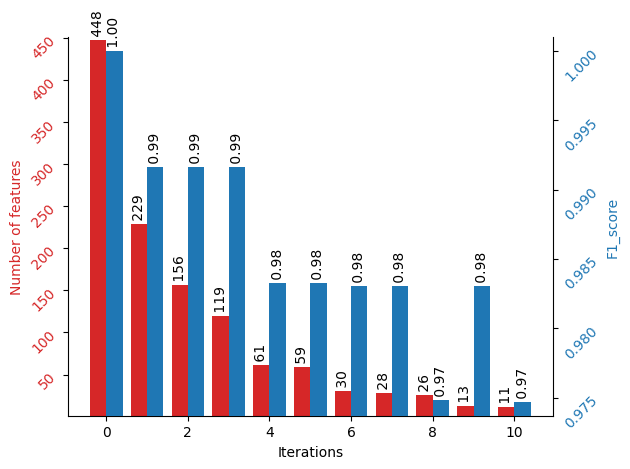

In [27]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_meat,y_meat,2,10,'MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\meat_mlp_icafs.png')

best f1 score= 0.92739898989899, iteration:1, numbers features selected =465,best features selected=812.3985, 891.508, 893.4375, 895.367, 897.2965, 899.226, 901.1555, 903.085, 905.0145, 906.944, 908.8735, 910.803, 912.7325, 914.662, 916.5915, 918.521, 922.38, 924.3095, 926.239, 928.1685, 930.098, 932.0275, 933.957, 935.8865, 937.816, 939.7455, 941.675, 943.6045, 945.534, 947.4645, 949.394, 951.3235, 953.253, 955.1825, 957.112, 959.0415, 960.971, 962.9005, 964.83, 966.7595, 968.689, 970.6185, 972.548, 974.4775, 976.407, 978.3365, 980.266, 982.1955, 984.125, 986.0545, 987.984, 989.9135, 991.843, 993.7725, 995.702, 997.6315, 999.561, 1001.4905, 1003.42, 1005.3495, 1007.279, 1009.2085, 1011.138, 1013.0675, 1014.997, 1016.9265, 1018.856, 1020.7855, 1022.715, 1024.6445, 1026.574, 1028.5035, 1030.433, 1032.3625, 1034.292, 1036.2215, 1038.151, 1040.0815, 1042.011, 1043.9405, 1045.87, 1047.7995, 1049.729, 1051.6585, 1053.588, 1055.5175, 1057.447, 1059.3765, 1061.306, 1063.2355, 1065.165, 1067.0

<Figure size 1100x1000 with 0 Axes>

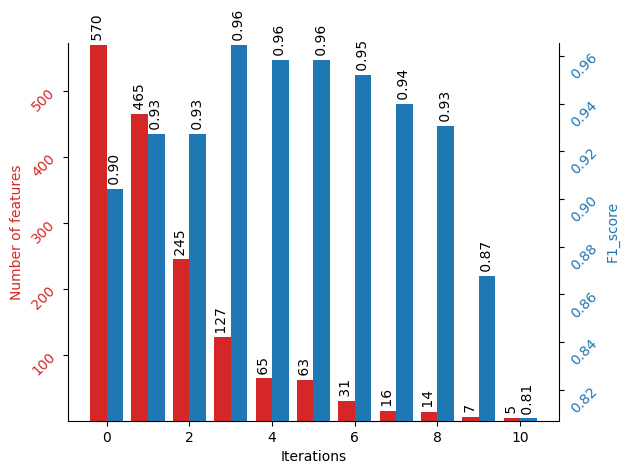

In [28]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_olive,y_olive,2,10,'MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\olive_icafs_mlp.png')